In [1]:
import os  # noqa: I001
from pathlib import Path
import warnings

from astropy.time import Time
from erfa import ErfaWarning
from rubin_scheduler.data import get_data_dir
from rubin_sim.phot_utils import Sed

from neo_detect.rubin_utils import filter_plot_colors
from neo_detect.survey_depth import OpSim_Depth

import matplotlib.pylab as plt
%matplotlib inline

/home/garcia/venv/neo_detect/lib64/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def calc_colors_smoke_test(sedname='S.dat', sed_dir=None):
    if sed_dir is None:
       sed_dir = os.path.join(get_data_dir(), "movingObjects")
    mo_sed = Sed()
    print(sed_dir, mo_sed)

In [3]:
print(get_data_dir(), os.path.exists(os.path.join(get_data_dir(), "movingObjects")))
calc_colors_smoke_test()

/home/garcia/rubin_sim_data True
/home/garcia/rubin_sim_data/movingObjects <rubin_sim.phot_utils.sed.Sed object at 0x7f8c6c2ff5d0>


## Look at OpSim database versus previous constant single band depth
### Read OpSim database, get back Pandas DataFrame
We read from `baseline.db` (which should be a symlink to the latest release, in this case baseline_v5.3.5_10yrs.db) in the subdirectories in the `RUBIN_SIM_DIR`

In [4]:
baseline_db = Path(get_data_dir()) / "sim_baseline" / "baseline.db"
rubin = OpSim_Depth(db_path=baseline_db.as_posix())
df = rubin.observations

In [5]:
print(f"Available columns in rubin.observations: {list(df.columns)}")
with warnings.catch_warnings():
    warnings.simplefilter('ignore', ErfaWarning)
    start_time = df['observationStartMJD'].min()
    t_start_time = Time(start_time, format='mjd', scale='utc')
    end_time = df['observationStartMJD'].max()
    t_end_time = Time(end_time, format='mjd', scale='utc')
    print(f"Observation time range: {t_start_time.to_datetime()} (MJD= {start_time:.6f}) to {t_end_time.to_datetime()} (MJD= {end_time:.6f})")

Available columns in rubin.observations: ['observationStartMJD', 'band', 'fiveSigmaDepth', 'airmass']
Observation time range: 2026-06-17 04:49:59.425275 (MJD= 61208.201382) to 2036-06-16 10:40:53.355109 (MJD= 64860.445062)


### Plot histograms of the 5 sigma band depths

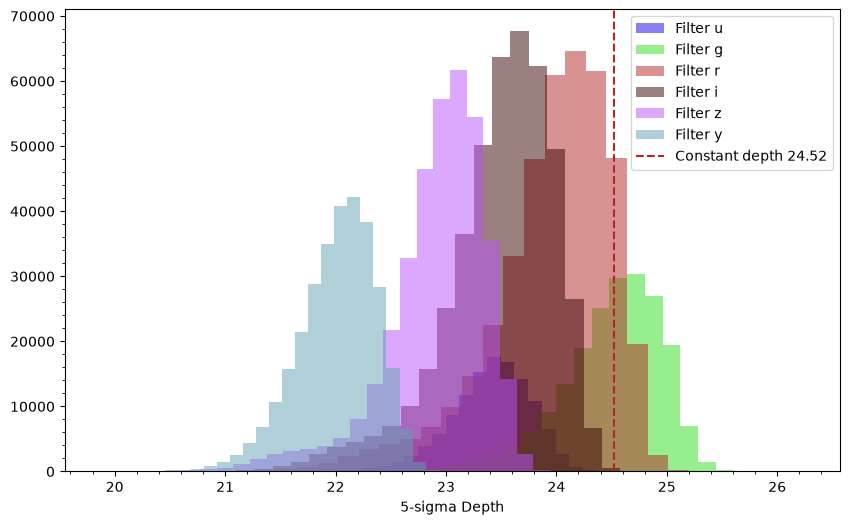

In [6]:
try:
    from datetime import UTC, datetime, timedelta
except ImportError:
    from datetime import datetime, timedelta, timezone
    UTC = timezone.utc  # noqa: UP017
from zoneinfo import ZoneInfo

from neo_detect.survey_depth import Constant_Depth

fig, ax = plt.subplots(figsize=(10, 6))
plot_colors = filter_plot_colors()
for band, color in plot_colors.items():
    # print(f"Filter {band} has color {color}")
    df_filtered = df.loc[df['band'] == band]
    ax.hist(df_filtered['fiveSigmaDepth'], bins=30, alpha=0.5, label=f'Filter {band}', color=color)

reference_depth = Constant_Depth().depth(datetime.now(tz=UTC))
ax.axvline(
    reference_depth,
    color=plot_colors['r'],
    linestyle='--',
    linewidth=1.5,
    label=f'Constant depth {reference_depth:.2f}',
)

ax.set_xlabel('5-sigma Depth')
ax.minorticks_on()
legend = ax.legend(loc='best')


### Examine variation of the band depth in different bands over 1 lunation (Full Moon to Full Moon)

In [7]:
# Full Moon times for 2026 from https://www.timeanddate.com/moon/phases/chile/la-serena?year=2026
full_moon_1 = Time(datetime(2026, 11, 24, 11, 53, 0, tzinfo=ZoneInfo('America/Santiago')), scale='utc')
new_moon_1  = Time(datetime(2026, 12, 8, 21, 51, 0, tzinfo=ZoneInfo('America/Santiago')), scale='utc')
full_moon_2 = Time(datetime(2026, 12, 23, 22, 28, 0, tzinfo=ZoneInfo('America/Santiago')), scale='utc')

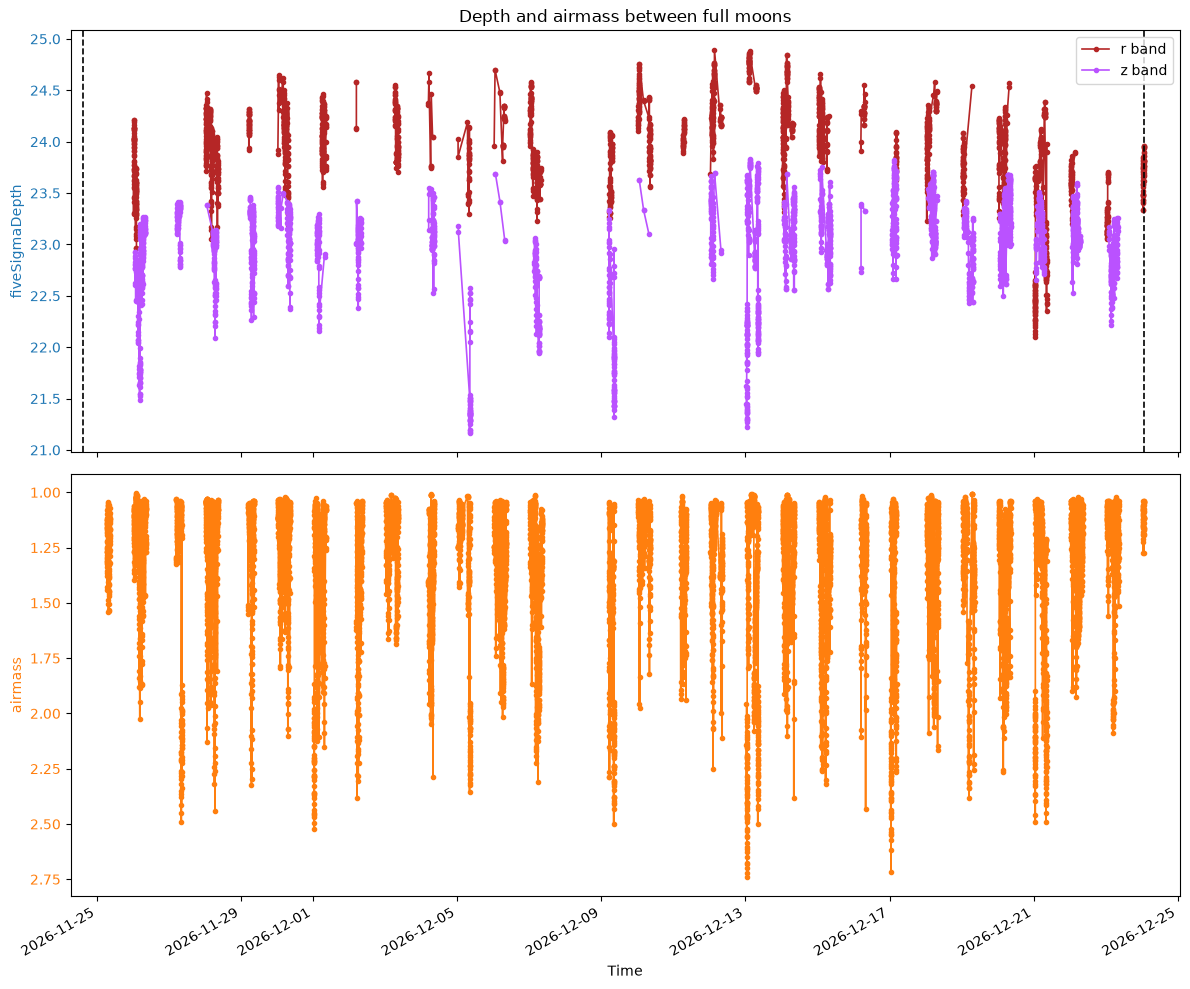

In [8]:
moon_mask = (df['observationStartMJD'] >= full_moon_1.mjd) & (df['observationStartMJD'] <= full_moon_2.mjd)
moon_df = df.loc[moon_mask].copy()
moon_df = moon_df.sort_values('observationStartMJD')

moon_times = Time(moon_df['observationStartMJD'], format='mjd', scale='utc').datetime
moon_df['datetime'] = moon_times

# Split by observing night so no line connects across the day gap
moon_df['night'] = moon_df['datetime'].dt.date

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

for band in ['r', 'z']:
    band_df = moon_df.loc[moon_df['band'] == band].copy()
    if band_df.empty:
        continue
    for i, (_, night_df) in enumerate(band_df.groupby('night')):
        label = f'{band} band' if i == 0 else None
        ax1.plot(night_df['datetime'], night_df['fiveSigmaDepth'], color=plot_colors[band], marker='.', linewidth=1.2, label=label)

plot_start = moon_df['datetime'].min() - timedelta(days=1)
plot_end = moon_df['datetime'].max() + timedelta(days=1)
for moon_time in [full_moon_1, full_moon_2]:
    if plot_start <= moon_time.datetime <= plot_end:
        ax1.axvline(moon_time.datetime, color='black', linestyle='--', linewidth=1.2)

ax1.set_ylabel('fiveSigmaDepth', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.set_title('Depth and airmass between full moons')
ax1.legend(loc='best')
ax1.set_xlim(plot_start, plot_end)

for _, night_df in moon_df.groupby('night'):
    ax2.plot(night_df['datetime'], night_df['airmass'], color='tab:orange', marker='.', linewidth=1.2)

ax2.set_ylabel('airmass', color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:orange')
ax2.invert_yaxis()
ax2.set_xlim(plot_start, plot_end)

ax2.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m-%d'))
fig.autofmt_xdate(rotation=30)
ax2.set_xlabel('Time')

fig.tight_layout()
plt.show()